# Convolutional Neural Network (CNN)

## 1. CNN là gì và vì sao cần nó?

CNN là một loại mạng nơ-ron giúp máy tính "nhìn" và hiểu ảnh, theo cách na ná cách con người nhận diện vật thể trong đời thực. Thay vì xem toàn bộ ảnh một lúc như mạng feedforward (ANN), CNN chia ảnh ra từng vùng nhỏ, tìm các đặc trưng cục bộ như đường thẳng, góc, vòng tròn, rồi ghép lại để đưa ra dự đoán.

### Một câu hỏi kinh điển: vì sao không dùng ANN cho ảnh?

Một ảnh 28×28 grayscale có 784 pixel. Nếu cho vào MLP (như bài MNIST trước), tầng đầu cần $784 \times 128 = 100.352$ tham số. Với ảnh màu 224×224×3, con số là $\sim 19$ triệu chỉ riêng tầng đầu. Hơn nữa, MLP coi mỗi pixel là một đặc trưng độc lập — nó *quên mất* rằng pixel cạnh nhau có quan hệ với nhau (cùng tạo nên một cái mắt, một cái mũi).

CNN giải quyết hai vấn đề này bằng:
1. **Chia sẻ trọng số** (weight sharing): cùng một filter dùng cho cả ảnh → ít tham số đi rất nhiều.
2. **Kết nối cục bộ** (local connectivity): mỗi neuron chỉ nhìn một vùng nhỏ → giữ được tính chất không gian của ảnh.

### Trực giác bằng ví dụ
Khi nhìn một con mèo, ta không xem hết cả ảnh ngay lập tức. Ta nhận ra tai mèo (hình tam giác), mắt mèo (hình tròn), ria mèo (đường thẳng), rồi não bộ mới kết luận "đây là mèo". CNN cũng làm vậy: dùng các "kính lúp" nhỏ (filter) quét qua ảnh, tìm từng đặc trưng nhỏ, càng lên các tầng sâu càng học được đặc trưng phức tạp.

## 2. Các thành phần chính của CNN

### 2.1. Tầng tích chập (Convolution Layer)

Đây là "đôi mắt" của CNN. Nó dùng một bộ lọc (filter / kernel) trượt qua ảnh, tại mỗi vị trí tính tích chập rồi sinh ra một con số trong feature map.

#### Công thức tích chập

$$
S(i, j) = \sum_{m=0}^{F-1} \sum_{n=0}^{F-1} I(i+m,\ j+n) \cdot K(m, n)
$$

Trong đó:
- $I$: ảnh đầu vào.
- $K$: filter kích thước $F \times F$.
- $S(i, j)$: giá trị tại vị trí $(i, j)$ trong feature map.

Đọc bằng lời: lấy vùng $F \times F$ của ảnh tại vị trí $(i, j)$, nhân từng phần tử với phần tử tương ứng của filter, rồi cộng tất cả lại.

*Lưu ý kỹ thuật:* trong toán học, tích chập "thật" có một bước lật filter; tích chập trong deep learning thực ra là **cross-correlation** (không lật). Nhưng vì filter được học từ dữ liệu nên việc lật hay không không quan trọng — kết quả huấn luyện như nhau.

### 2.2. Minh hoạ đầy đủ với số "7"

Hãy khám phá tầng tích chập qua một ví dụ cụ thể. Ta dùng filter phát hiện đường ngang để tìm nét trên cùng của số "7".

**Ảnh đầu vào (6×6):**
$$ I = \begin{bmatrix} 1 & 1 & 1 & 1 & 1 & 1 \\ 0 & 0 & 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 & 0 & 0 \\ 1 & 0 & 0 & 0 & 0 & 0 \end{bmatrix} $$

Hàng trên cùng toàn 1 = nét ngang, các hàng dưới có một số 1 chéo từ phải sang trái = thân số 7.

**Filter phát hiện đường ngang (3×3):**
$$ K = \begin{bmatrix} 1 & 1 & 1 \\ 0 & 0 & 0 \\ -1 & -1 & -1 \end{bmatrix} $$

Filter này phản hồi mạnh khi vùng dưới của patch tối, vùng trên sáng — đặc trưng của một đường ngang nét đậm trên nền trắng phía dưới.

**Kích thước feature map:** với stride 1, không padding:
$$\text{output} = \Big\lfloor\frac{6-3}{1}\Big\rfloor + 1 = 4$$
→ feature map 4×4.

#### Tính từng vị trí

Đối với mỗi vị trí $(i, j)$ của output, ta lấy patch $I[i:i+3,\ j:j+3]$, nhân từng phần tử với $K$, rồi cộng dồn.

**$(0, 0)$:** patch = $\begin{bmatrix}1&1&1\\0&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1+1+1 = 3$

**$(0, 1)$:** patch = $\begin{bmatrix}1&1&1\\0&0&0\\0&0&1\end{bmatrix}$ → tổng $= 3 + 0 + (-1) = 2$

**$(0, 2)$:** patch = $\begin{bmatrix}1&1&1\\0&0&1\\0&1&0\end{bmatrix}$ → tổng $= 3 + 0 + (-1) = 2$

**$(0, 3)$:** patch = $\begin{bmatrix}1&1&1\\0&1&0\\1&0&0\end{bmatrix}$ → tổng $= 3 + 0 + (-1) = 2$

**$(1, 0)$:** patch = $\begin{bmatrix}0&0&0\\0&0&0\\0&0&1\end{bmatrix}$ → tổng $= 0 + 0 + (-1) = -1$

**$(1, 1)$:** patch = $\begin{bmatrix}0&0&0\\0&0&1\\0&1&0\end{bmatrix}$ → tổng $= 0 + 0 + (-1) = -1$  *(không phải +1, đây là chỗ cần chú ý kẻo nhầm dấu)*

**$(1, 2)$:** patch = $\begin{bmatrix}0&0&1\\0&1&0\\1&0&0\end{bmatrix}$ → tổng $= 1 + 0 + (-1) = 0$

**$(1, 3)$:** patch = $\begin{bmatrix}0&1&0\\1&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(2, 0)$:** patch = $\begin{bmatrix}0&0&0\\0&0&1\\0&1&0\end{bmatrix}$ → tổng $= 0 + 0 + (-1) = -1$

**$(2, 1)$:** patch = $\begin{bmatrix}0&0&1\\0&1&0\\1&0&0\end{bmatrix}$ → tổng $= 1 + 0 + (-1) = 0$

**$(2, 2)$:** patch = $\begin{bmatrix}0&1&0\\1&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(2, 3)$:** patch = $\begin{bmatrix}1&0&0\\0&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(3, 0)$:** patch = $\begin{bmatrix}0&0&1\\0&1&0\\1&0&0\end{bmatrix}$ → tổng $= 1 + 0 + (-1) = 0$

**$(3, 1)$:** patch = $\begin{bmatrix}0&1&0\\1&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(3, 2)$:** patch = $\begin{bmatrix}1&0&0\\0&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(3, 3)$:** patch = $\begin{bmatrix}0&0&0\\0&0&0\\0&0&0\end{bmatrix}$ → tổng $= 0$

**Feature map hoàn chỉnh:**
$$ S = \begin{bmatrix} 3 & 2 & 2 & 2 \\ -1 & -1 & 0 & 1 \\ -1 & 0 & 1 & 1 \\ 0 & 1 & 1 & 0 \end{bmatrix} $$

Nhìn vào feature map: dòng đầu có giá trị lớn (2-3) — filter "kêu to" nhất ở vùng có nét ngang trên cùng. Đó chính là điều ta muốn: filter đã phát hiện đúng vị trí đường ngang của số 7.

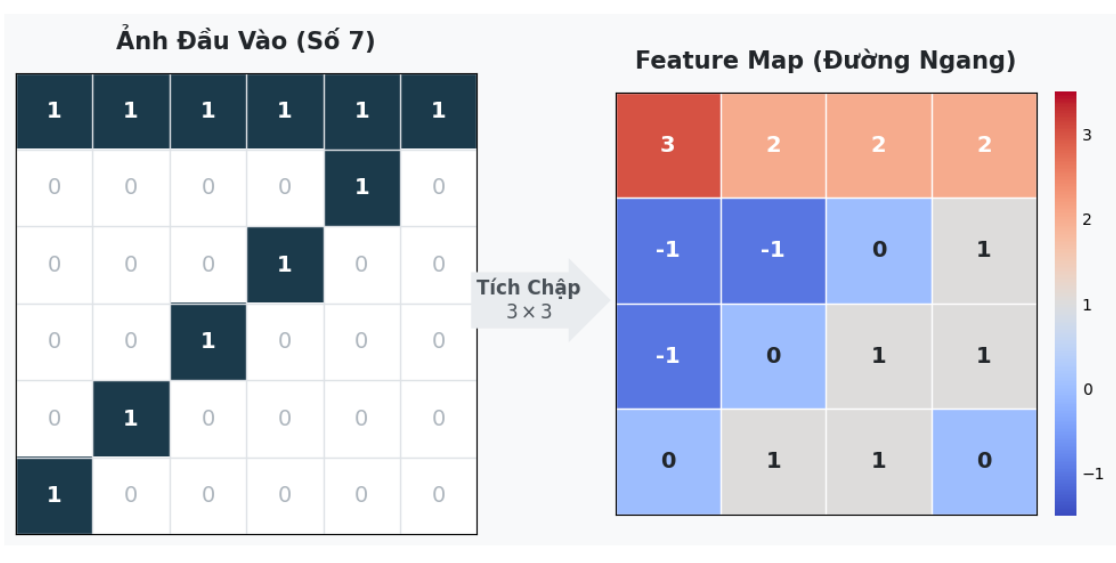


#### Padding và Stride

- **Padding ($P$)**: thêm số 0 quanh ảnh. Nếu $P=0$ (như trên), feature map nhỏ hơn ảnh gốc. Padding `'same'` thêm vừa đủ để output cùng kích thước input.
- **Stride ($S$)**: bước trượt của filter. $S=1$ trượt từng pixel, $S=2$ nhảy cách 2 pixel — output nhỏ đi một nửa.

Công thức kích thước đầu ra (với phép chia làm tròn xuống):
$$
\text{Output Height} = \Big\lfloor\frac{H - F + 2P}{S}\Big\rfloor + 1
$$
$$
\text{Output Width} = \Big\lfloor\frac{W - F + 2P}{S}\Big\rfloor + 1
$$

Kiểm tra với ví dụ: $H = W = 6$, $F=3$, $P=0$, $S=1$ → $(6-3)/1 + 1 = 4$, đúng với feature map 4×4.

### 2.3. Hàm kích hoạt ReLU

Sau khi có feature map, ta áp dụng ReLU để loại bỏ các giá trị âm. Ý tưởng: giá trị âm thường nghĩa là vùng đó *không* có đặc trưng filter đang tìm — bỏ đi cho đỡ ồn.

$$ \text{ReLU}(x) = \max(0, x) $$

Áp dụng vào feature map ở trên:

$$ \text{ReLU}(S) = \begin{bmatrix} 3 & 2 & 2 & 2 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 1 \\ 0 & 1 & 1 & 0 \end{bmatrix} $$

Các -1 đã bị nén về 0. Vì sao chọn ReLU thay vì sigmoid hay tanh? Vì sigmoid và tanh có gradient bão hoà ở vùng giá trị lớn — gradient gần 0 → mạng học rất chậm khi đi sâu. ReLU tránh được vấn đề này (gradient là 1 với x > 0).

### 2.4. Tầng Pooling

Pooling "tóm tắt" feature map, giảm kích thước nhưng giữ thông tin chính. Loại phổ biến nhất: **Max Pooling** — trong mỗi vùng nhỏ chỉ giữ giá trị lớn nhất.

Áp dụng max pooling 2×2 stride 2 lên feature map sau ReLU:

- Vùng góc trên trái $\{3, 2, 0, 0\}$ → max = 3
- Vùng góc trên phải $\{2, 2, 0, 1\}$ → max = 2
- Vùng góc dưới trái $\{0, 0, 0, 1\}$ → max = 1
- Vùng góc dưới phải $\{1, 1, 1, 0\}$ → max = 1

$$ P = \begin{bmatrix} 3 & 2 \\ 1 & 1 \end{bmatrix} $$

Ngoài giảm kích thước (giúp tính nhanh hơn), pooling còn cho mạng tính **bất biến với dịch chuyển nhỏ**: nếu ảnh dịch sang phải vài pixel, max pooling vẫn ra cùng một giá trị.

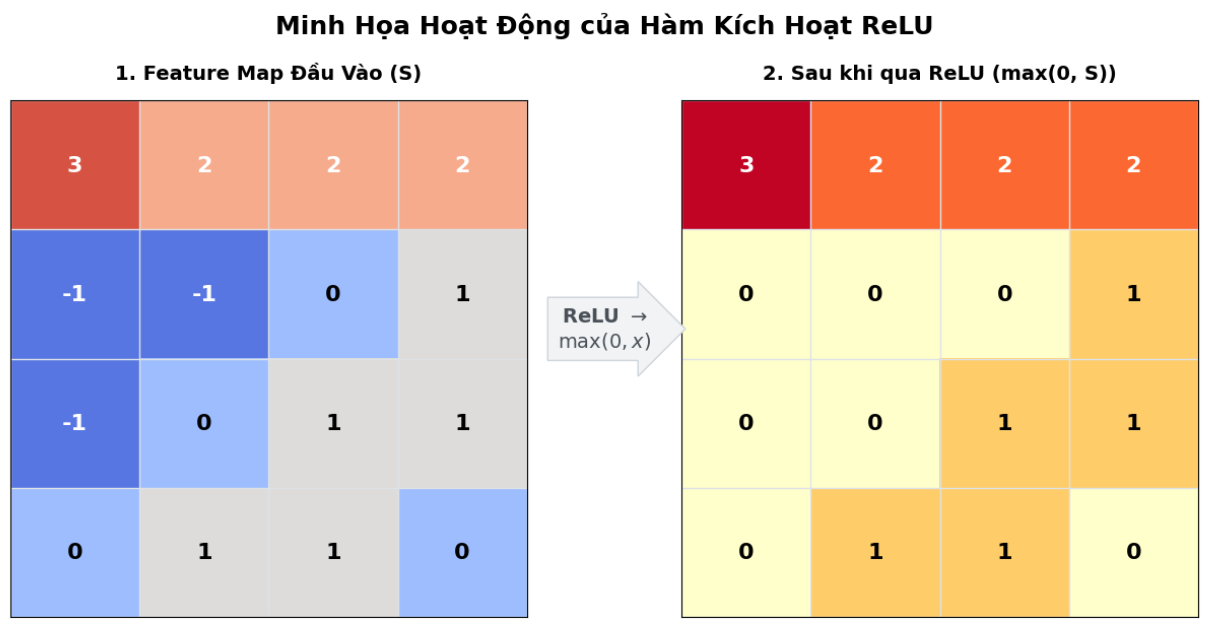


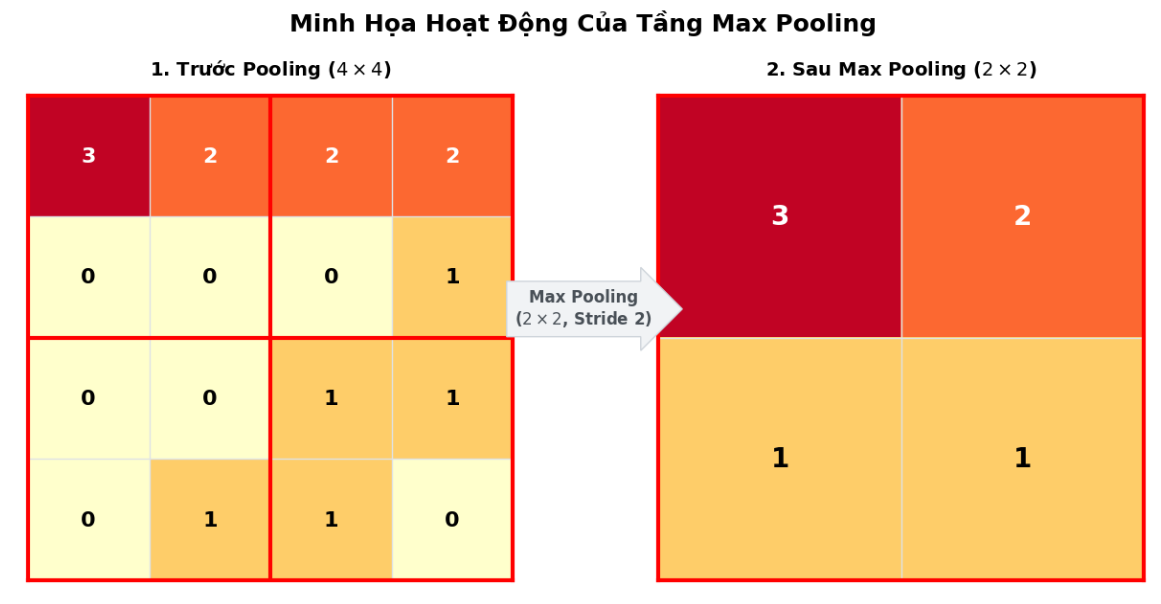


### 2.5. Tầng Fully Connected

Sau vài tầng conv + pool, ta "duỗi" feature map cuối thành vector và đưa qua một tầng Linear thông thường — đây là bước "ghép các đặc trưng lại để ra quyết định".

$$ y = Wx + b $$

**Ví dụ:** lấy feature map sau pooling = $\begin{bmatrix}3 & 2 \\ 1 & 1\end{bmatrix}$, duỗi thành $x = [3, 2, 1, 1]$.

Phân loại 2 lớp: "là 7" / "không phải 7". Cho:
$$ W = \begin{bmatrix} 0.5 & 0.2 & 0.3 & 0.4 \\ -0.1 & 0.3 & 0.2 & -0.5 \end{bmatrix},\quad b = \begin{bmatrix}0.1\\0.2\end{bmatrix} $$

Tính từng output:
- $y_0 = (0.5 \cdot 3 + 0.2 \cdot 2 + 0.3 \cdot 1 + 0.4 \cdot 1) + 0.1 = (1.5 + 0.4 + 0.3 + 0.4) + 0.1 = 2.6 + 0.1 = 2.7$
- $y_1 = (-0.1 \cdot 3 + 0.3 \cdot 2 + 0.2 \cdot 1 + (-0.5) \cdot 1) + 0.2 = (-0.3 + 0.6 + 0.2 - 0.5) + 0.2 = 0.0 + 0.2 = 0.2$

Sau softmax:
$$P(\text{là 7}) = \frac{e^{2.7}}{e^{2.7} + e^{0.2}} \approx 0.924$$
$$P(\text{không phải 7}) = \frac{e^{0.2}}{e^{2.7} + e^{0.2}} \approx 0.076$$

Mạng kết luận: 92.4% xác suất là số 7.

## 3. Tóm tắt pipeline CNN

1. **Conv** → tìm đặc trưng cục bộ → feature map.
2. **ReLU** → giữ tín hiệu dương, bỏ tín hiệu âm.
3. **Pool** → tóm tắt + giảm kích thước.
4. (Lặp lại 1-3 nhiều lần để học đặc trưng từ thấp đến cao.)
5. **Flatten + FC** → ra quyết định cuối cùng.
6. **Softmax + CrossEntropy** (lúc train) → tính loss.

Càng đi sâu vào mạng, các filter càng học được đặc trưng phức tạp hơn: tầng đầu phát hiện cạnh, tầng giữa phát hiện hình tròn / góc, tầng cuối phát hiện cả "con mèo" hay "chữ số 7".

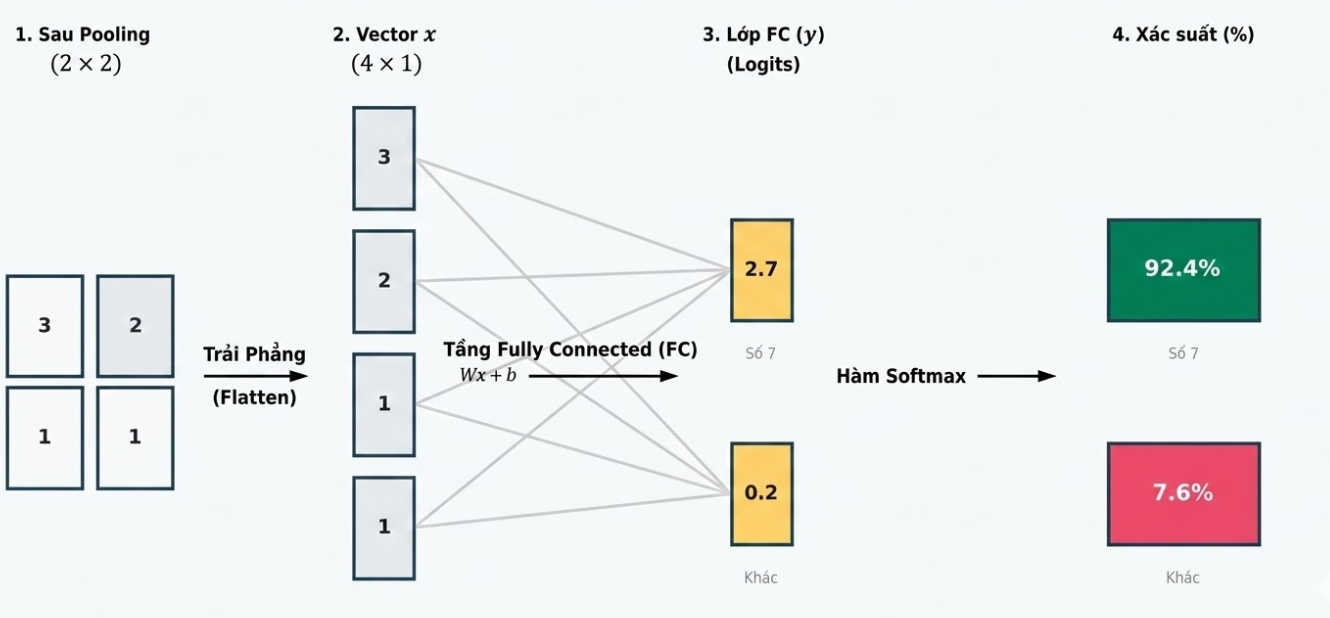


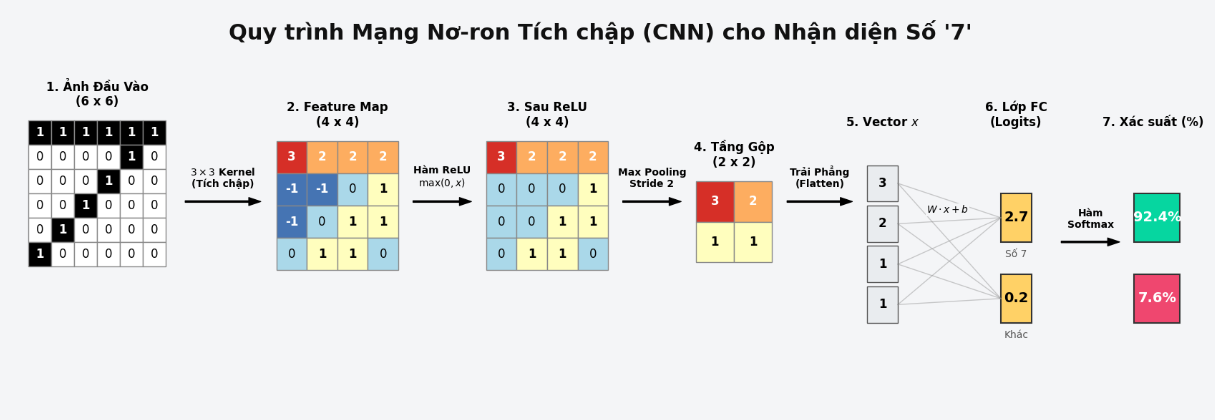


# BÀI THỰC HÀNH: PHÂN LOẠI MNIST BẰNG CNN

Ở bài MNIST với ANN, ta đạt khoảng 97-98% test accuracy. Bây giờ ta sẽ thấy CNN có thể vượt 99% với *ít tham số hơn*.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [2]:
# Chuẩn hoá MNIST với mean/std của tập train.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f'Số ảnh train: {len(train_dataset)},  test: {len(test_dataset)}')

100.0%
100.0%
100.0%
100.0%

Số ảnh train: 60000,  test: 10000


## Kiến trúc model

```
Input  (1, 28, 28)
  │
Conv1 (1→16, k=3) → 16, 26, 26      vì (28-3)/1 + 1 = 26
  │ ReLU + MaxPool 2×2
  → (16, 13, 13)                     26 / 2 = 13
  │
Conv2 (16→32, k=3) → 32, 11, 11      vì (13-3)/1 + 1 = 11
  │ ReLU + MaxPool 2×2
  → (32, 5, 5)                       floor(11/2) = 5
  │ Flatten → 800
  │
FC (800 → 10) → logits
```

Lưu ý số 5×5 ở cuối: vì 11 lẻ nên max pool 2×2 cho ra 5 (làm tròn xuống). Sinh viên hay mắc lỗi tính nhầm chỗ này, dẫn đến `nn.Linear` sai chiều và chương trình lỗi shape mismatch.

In [3]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)   # 28→26
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # 13→11
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # → (16, 13, 13)
        x = self.pool(torch.relu(self.conv2(x)))   # → (32,  5,  5)
        x = x.view(x.size(0), -1)                  # flatten
        x = self.fc1(x)                            # logits
        return x

model = MNIST_CNN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Tổng tham số: {n_params:,}')

# So sánh nhanh với ANN(784→128→10) ở bài trước: ~101 nghìn params và ~97% acc.
# CNN này thường ít tham số hơn (~13 nghìn) mà acc cao hơn.

MNIST_CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=800, out_features=10, bias=True)
)
Tổng tham số: 12,810


In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

## Huấn luyện

Tracking đúng cách: cộng dồn loss theo *số mẫu*, không theo *số batch* (vì batch cuối có thể nhỏ hơn).

In [5]:
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

num_epochs = 5
loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model, test_loader)
    loss_history.append(train_loss); acc_history.append(train_acc)
    test_loss_history.append(test_loss); test_acc_history.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
          f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')

Epoch 1/5  train_loss=0.1824  train_acc=94.29%  test_loss=0.0632  test_acc=97.92%
Epoch 2/5  train_loss=0.0650  train_acc=98.06%  test_loss=0.0562  test_acc=98.13%
Epoch 3/5  train_loss=0.0495  train_acc=98.52%  test_loss=0.0411  test_acc=98.70%
Epoch 4/5  train_loss=0.0422  train_acc=98.69%  test_loss=0.0501  test_acc=98.47%
Epoch 5/5  train_loss=0.0370  train_acc=98.80%  test_loss=0.0425  test_acc=98.55%


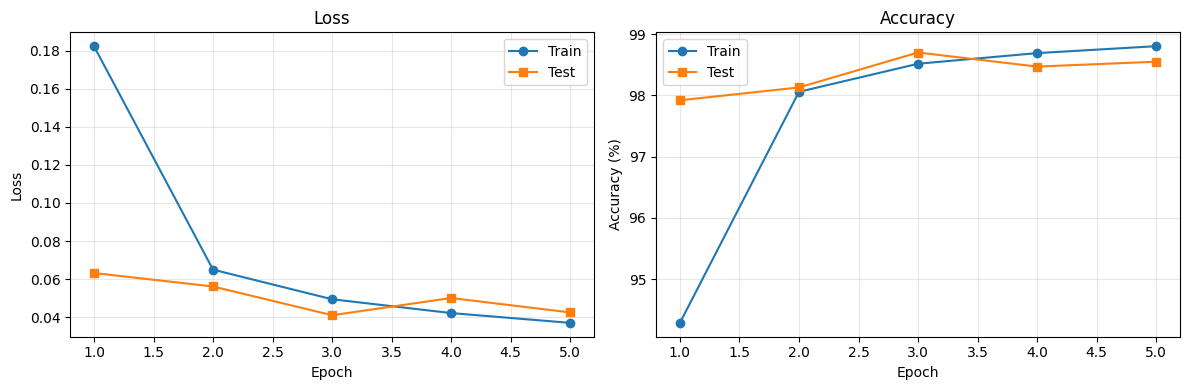

In [6]:
epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_history,      'o-', label='Train')
axes[0].plot(epochs, test_loss_history, 's-', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss')
axes[1].plot(epochs, [a*100 for a in acc_history],      'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_history], 's-', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Accuracy')
plt.tight_layout(); plt.show()

## Đánh giá trên test set

In [7]:
test_loss, test_acc = evaluate(model, test_loader)
print(f'Final test accuracy: {test_acc*100:.2f}%')
print(f'(MNIST-ANN ở bài trước đạt ~97-98%; CNN nhỏ này thường đạt 98.5-99%.)')

Final test accuracy: 98.55%
(MNIST-ANN ở bài trước đạt ~97-98%; CNN nhỏ này thường đạt 98.5-99%.)


## Trực quan: model dự đoán

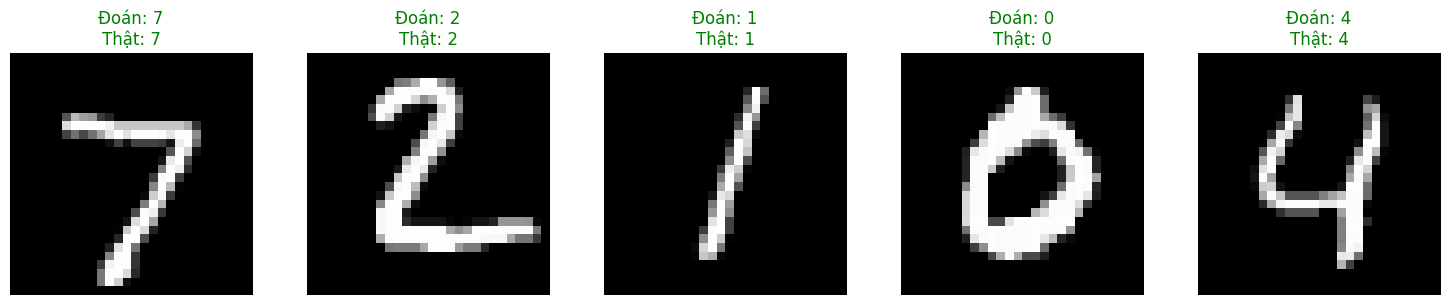

In [8]:
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    preds = model(images).argmax(1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = images[i].cpu().squeeze() * 0.3081 + 0.1307   # un-normalize để nhìn cho đẹp
    axes[i].imshow(img, cmap='gray')
    color = 'green' if preds[i] == labels[i] else 'red'
    axes[i].set_title(f'Đoán: {preds[i].item()}\nThật: {labels[i].item()}', color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

## Trực quan: feature maps

Nhìn xem các filter của tầng conv1 đã học được điều gì.

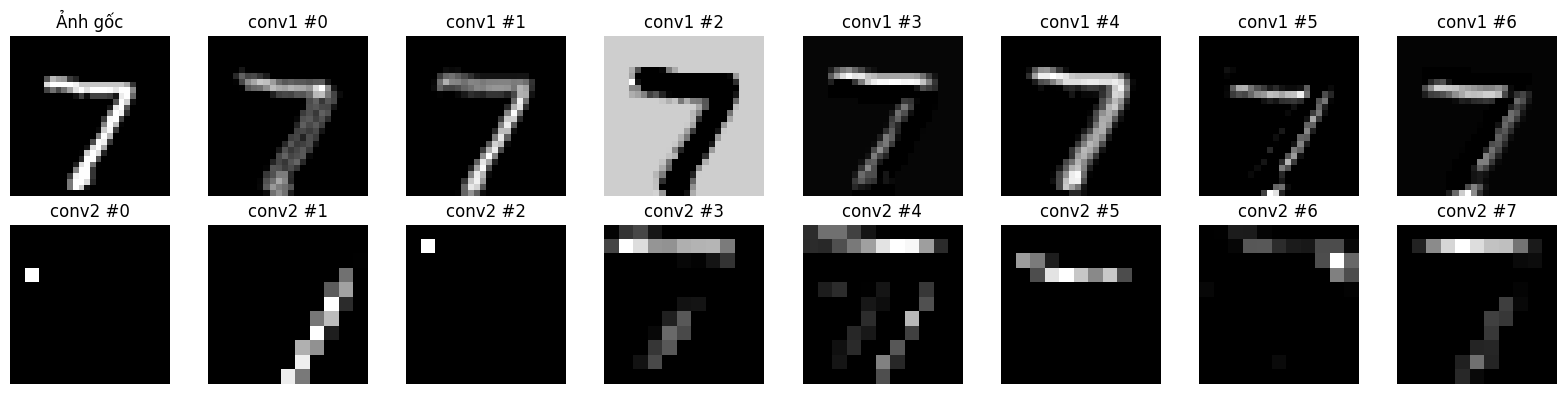

Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.
         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)


In [9]:
model.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    fmap1 = torch.relu(model.conv1(img))           # (1, 16, 26, 26)
    fmap2 = torch.relu(model.conv2(model.pool(fmap1)))  # (1, 32, 11, 11)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
axes[0, 0].imshow(img.cpu().squeeze() * 0.3081 + 0.1307, cmap='gray')
axes[0, 0].set_title('Ảnh gốc'); axes[0, 0].axis('off')
for i in range(7):
    axes[0, i+1].imshow(fmap1[0, i].cpu(), cmap='gray')
    axes[0, i+1].set_title(f'conv1 #{i}'); axes[0, i+1].axis('off')
for i in range(8):
    axes[1, i].imshow(fmap2[0, i].cpu(), cmap='gray')
    axes[1, i].set_title(f'conv2 #{i}'); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

print('Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.')
print('         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)')

# BÀI TẬP VỀ NHÀ

Nộp file `.ipynb` lên GitHub. Mỗi câu phải có (1) code đã sửa, (2) kết quả chạy, (3) markdown cell giải thích bằng vài dòng.

## Câu 1: Train lâu hơn
Tăng số epoch từ 5 lên 10. Báo cáo:
- Test accuracy sau epoch 10 so với epoch 5 — chênh nhau bao nhiêu?
- Khoảng cách `train_acc - test_acc` mở rộng dần không? Đó là dấu hiệu gì?

*Gợi ý:* sửa `num_epochs = 10`, không cần đổi gì khác. Nếu thấy gap mở rộng → overfitting bắt đầu xuất hiện.

## Câu 2: Thêm tầng tích chập thứ ba
Thêm `conv3` để mạng sâu hơn.
- Trong `__init__`: thêm `self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)`. Dùng `padding=1` để giữ kích thước không bị giảm thêm.
- Trong `forward`: thêm `x = self.pool(torch.relu(self.conv3(x)))` sau conv2.
- Tính lại kích thước feature map: sau conv2 + pool ta có `(32, 5, 5)`. Sau conv3 padding=1: `(64, 5, 5)`. Sau pool: `(64, 2, 2)` (vì floor(5/2)=2).
- Đổi `fc1 = nn.Linear(64 * 2 * 2, 10)`.

*Gợi ý:* Nếu code lỗi shape mismatch, in `print(x.shape)` ngay trước `view` để tìm chiều thật.

## Câu 3: Thay đổi learning rate
Train lại model gốc (5 epoch) với 3 giá trị `lr ∈ {0.001, 0.01, 0.1}`. Vẽ 3 đường loss trên cùng đồ thị.
- Quan sát: lr nào quá thấp (loss giảm chậm)? lr nào quá cao (loss dao động hoặc bùng nổ)?
- Trong báo cáo: giải thích vì sao `lr` ảnh hưởng đến hành vi học.

## Câu 4: Vẽ thêm feature maps từ conv2
Sửa hàm hiển thị feature maps để trực quan thêm 2 feature map từ tầng conv2 (đã có sẵn ở cell `cnn-cell-09` ở trên — em chỉ cần đọc kỹ và viết lại theo cách của mình).

*Gợi ý cách lấy feature map của conv2 từ ngoài class:*
```python
with torch.no_grad():
    h1 = torch.relu(model.conv1(img))
    h1 = model.pool(h1)
    h2 = torch.relu(model.conv2(h1))   # đây là feature map của conv2
```
Sau đó vẽ một số kênh trong `h2` bằng `imshow`.

Trong báo cáo: so sánh feature map của conv1 và conv2 — feature map nào cụ thể hơn (cạnh, viền), feature map nào trừu tượng hơn?

## Câu 5: Thêm Dropout và Data Augmentation
- Thêm `nn.Dropout(p=0.25)` sau pool cuối cùng và trước `fc1`.
- Thêm augmentation vào `transform` lúc train: `transforms.RandomAffine(degrees=10, translate=(0.1, 0.1))`. Lưu ý: chỉ áp dụng cho train, KHÔNG áp dụng cho test.
- Train 10 epoch, so sánh test acc với mô hình không có dropout/augmentation.

Báo cáo: dropout và augmentation giúp giảm overfitting như thế nào?

## Deadline
23h59 ngày 11/03/2026.

# PHẦN LÀM BÀI TẬP VỀ NHÀ

Các cell dưới đây giữ nguyên dữ liệu MNIST và hàm `evaluate()` của bài lab.  
Chạy lần lượt từ trên xuống để có đủ: code đã sửa, kết quả chạy, và nhận xét cho từng câu.

In [10]:
# Cell hỗ trợ chung cho các câu bài tập

def dem_tham_so(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_model_cnn(model, train_loader, test_loader, num_epochs=5, lr=0.01, momentum=0.9, ten_model='model'):
    # Train model CNN và trả về lịch sử train/test loss, accuracy.
    # Dùng lại criterion = CrossEntropyLoss giống bài lab.
    model = model.to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)

    lich_su = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': []
    }

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        test_loss, test_acc = evaluate(model, test_loader)

        lich_su['train_loss'].append(train_loss)
        lich_su['train_acc'].append(train_acc)
        lich_su['test_loss'].append(test_loss)
        lich_su['test_acc'].append(test_acc)

        print(
            f'{ten_model} | Epoch [{epoch+1:02d}/{num_epochs}] '
            f'Train loss: {train_loss:.4f} | Train acc: {train_acc*100:.2f}% | '
            f'Test loss: {test_loss:.4f} | Test acc: {test_acc*100:.2f}%'
        )

    return model, lich_su

## Câu 1: Train lâu hơn

Yêu cầu: tăng số epoch từ 5 lên 10, sau đó so sánh test accuracy ở epoch 5 và epoch 10.  
Mô hình vẫn dùng kiến trúc CNN gốc, optimizer gốc `SGD(lr=0.01, momentum=0.9)`.

Câu 1 - CNN gốc | Epoch [01/10] Train loss: 0.1824 | Train acc: 94.29% | Test loss: 0.0632 | Test acc: 97.92%
Câu 1 - CNN gốc | Epoch [02/10] Train loss: 0.0650 | Train acc: 98.06% | Test loss: 0.0562 | Test acc: 98.13%
Câu 1 - CNN gốc | Epoch [03/10] Train loss: 0.0495 | Train acc: 98.52% | Test loss: 0.0411 | Test acc: 98.70%
Câu 1 - CNN gốc | Epoch [04/10] Train loss: 0.0422 | Train acc: 98.69% | Test loss: 0.0501 | Test acc: 98.47%
Câu 1 - CNN gốc | Epoch [05/10] Train loss: 0.0370 | Train acc: 98.80% | Test loss: 0.0425 | Test acc: 98.55%
Câu 1 - CNN gốc | Epoch [06/10] Train loss: 0.0316 | Train acc: 99.06% | Test loss: 0.0327 | Test acc: 99.01%
Câu 1 - CNN gốc | Epoch [07/10] Train loss: 0.0283 | Train acc: 99.08% | Test loss: 0.0356 | Test acc: 98.89%
Câu 1 - CNN gốc | Epoch [08/10] Train loss: 0.0251 | Train acc: 99.18% | Test loss: 0.0364 | Test acc: 98.86%
Câu 1 - CNN gốc | Epoch [09/10] Train loss: 0.0221 | Train acc: 99.28% | Test loss: 0.0378 | Test acc: 98.78%
Câu 1 - CN

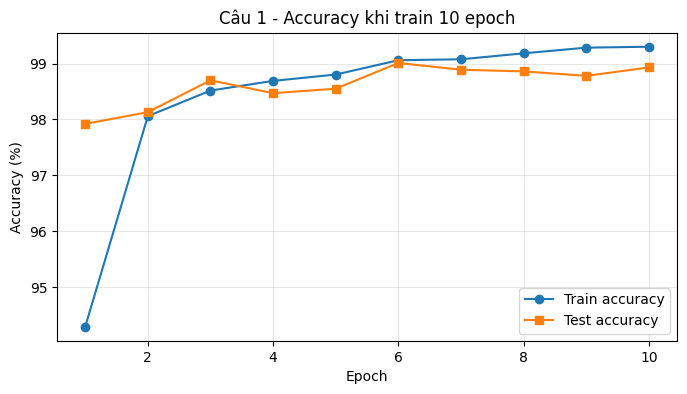

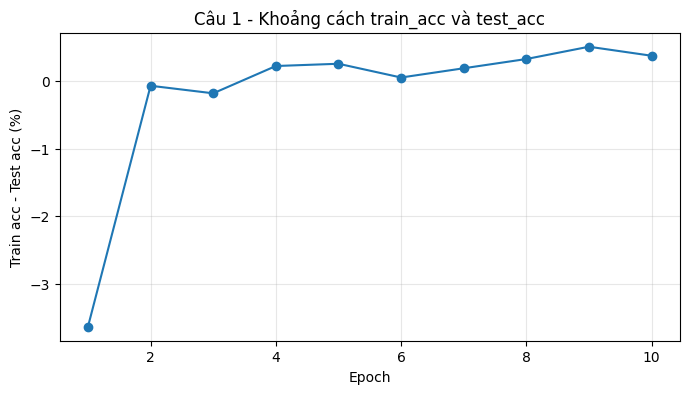

In [11]:
# Câu 1: Train model gốc trong 10 epoch

torch.manual_seed(42)
np.random.seed(42)

model_cau1 = MNIST_CNN().to(device)

model_cau1, lich_su_cau1 = train_model_cnn(
    model=model_cau1,
    train_loader=train_loader,
    test_loader=test_loader,
    num_epochs=10,
    lr=0.01,
    momentum=0.9,
    ten_model='Câu 1 - CNN gốc'
)

acc_epoch_5 = lich_su_cau1['test_acc'][4]
acc_epoch_10 = lich_su_cau1['test_acc'][9]
chenh_lech_acc = acc_epoch_10 - acc_epoch_5

gap_train_test = [
    train_acc - test_acc
    for train_acc, test_acc in zip(lich_su_cau1['train_acc'], lich_su_cau1['test_acc'])
]

print('\nKẾT QUẢ CÂU 1')
print(f'Test accuracy epoch 5 : {acc_epoch_5*100:.2f}%')
print(f'Test accuracy epoch 10: {acc_epoch_10*100:.2f}%')
print(f'Chênh lệch epoch 10 - epoch 5: {chenh_lech_acc*100:.2f}%')
print(f'Gap train_acc - test_acc epoch 5 : {gap_train_test[4]*100:.2f}%')
print(f'Gap train_acc - test_acc epoch 10: {gap_train_test[9]*100:.2f}%')

epochs_cau1 = range(1, 11)

plt.figure(figsize=(8, 4))
plt.plot(epochs_cau1, [a * 100 for a in lich_su_cau1['train_acc']], 'o-', label='Train accuracy')
plt.plot(epochs_cau1, [a * 100 for a in lich_su_cau1['test_acc']], 's-', label='Test accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Câu 1 - Accuracy khi train 10 epoch')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs_cau1, [g * 100 for g in gap_train_test], 'o-')
plt.xlabel('Epoch')
plt.ylabel('Train acc - Test acc (%)')
plt.title('Câu 1 - Khoảng cách train_acc và test_acc')
plt.grid(alpha=0.3)
plt.show()

**Nhận xét Câu 1:**  
Khi tăng từ 5 epoch lên 10 epoch, test accuracy thường tăng nhẹ vì mô hình được học lâu hơn.  
Nếu khoảng cách `train_acc - test_acc` tăng dần, nghĩa là mô hình học tốt trên tập train hơn tập test. Đây là dấu hiệu overfitting bắt đầu xuất hiện.  
Nếu gap vẫn nhỏ, mô hình chưa bị overfitting rõ rệt.

## Câu 2: Thêm tầng tích chập thứ ba

Yêu cầu: thêm `conv3` sau `conv2`.  
Sau `conv2 + pool`, kích thước đang là `(32, 5, 5)`.  
Thêm `conv3 = Conv2d(32, 64, kernel_size=3, padding=1)` sẽ giữ kích thước `5 x 5`.  
Sau `pool` lần nữa, kích thước còn `(64, 2, 2)`, nên `fc1 = Linear(64 * 2 * 2, 10)`.

In [12]:
# Câu 2: Model CNN có thêm tầng conv3

class MNIST_CNN_3Conv(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)    # 28 -> 26
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)   # 13 -> 11
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)   # 5 -> 5
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 2 * 2, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))  # (16, 13, 13)
        x = self.pool(torch.relu(self.conv2(x)))  # (32, 5, 5)
        x = self.pool(torch.relu(self.conv3(x)))  # (64, 2, 2)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

torch.manual_seed(42)
np.random.seed(42)

model_cau2 = MNIST_CNN_3Conv().to(device)
print(model_cau2)
print(f'Tổng tham số model 3 conv: {dem_tham_so(model_cau2):,}')

# Kiểm tra shape trước khi train
x_mau, _ = next(iter(train_loader))
x_mau = x_mau[:4].to(device)
with torch.no_grad():
    h = model_cau2.pool(torch.relu(model_cau2.conv1(x_mau)))
    print('Sau conv1 + pool:', h.shape)
    h = model_cau2.pool(torch.relu(model_cau2.conv2(h)))
    print('Sau conv2 + pool:', h.shape)
    h = model_cau2.pool(torch.relu(model_cau2.conv3(h)))
    print('Sau conv3 + pool:', h.shape)
    print('Sau flatten:', h.view(h.size(0), -1).shape)

model_cau2, lich_su_cau2 = train_model_cnn(
    model=model_cau2,
    train_loader=train_loader,
    test_loader=test_loader,
    num_epochs=5,
    lr=0.01,
    momentum=0.9,
    ten_model='Câu 2 - CNN 3 conv'
)

print('\nKẾT QUẢ CÂU 2')
print(f'Test accuracy cuối cùng: {lich_su_cau2["test_acc"][-1]*100:.2f}%')
print(f'Test loss cuối cùng: {lich_su_cau2["test_loss"][-1]:.4f}')

MNIST_CNN_3Conv(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=256, out_features=10, bias=True)
)
Tổng tham số model 3 conv: 25,866
Sau conv1 + pool: torch.Size([4, 16, 13, 13])
Sau conv2 + pool: torch.Size([4, 32, 5, 5])
Sau conv3 + pool: torch.Size([4, 64, 2, 2])
Sau flatten: torch.Size([4, 256])
Câu 2 - CNN 3 conv | Epoch [01/5] Train loss: 0.2482 | Train acc: 91.99% | Test loss: 0.0766 | Test acc: 97.53%
Câu 2 - CNN 3 conv | Epoch [02/5] Train loss: 0.0594 | Train acc: 98.16% | Test loss: 0.0412 | Test acc: 98.75%
Câu 2 - CNN 3 conv | Epoch [03/5] Train loss: 0.0431 | Train acc: 98.64% | Test loss: 0.0373 | Test acc: 98.81%
Câu 2 - CNN 3 conv | Epoch [04/5] Train loss: 0.0346 | Train acc: 98.91% | Test loss: 0.0401 | Test

**Nhận xét Câu 2:**  
Model có thêm `conv3` sâu hơn model gốc, nên có khả năng học đặc trưng phức tạp hơn.  
Tuy nhiên số tham số tăng lên, thời gian train cũng lâu hơn.  
Nếu test accuracy tăng, tầng conv3 giúp mô hình học đặc trưng tốt hơn. Nếu accuracy không tăng nhiều, bài toán MNIST có thể đã đủ đơn giản với 2 tầng conv.

## Câu 3: Thay đổi learning rate

Yêu cầu: train lại model gốc trong 5 epoch với 3 learning rate: `0.001`, `0.01`, `0.1`.  
Sau đó vẽ 3 đường loss trên cùng đồ thị để so sánh tốc độ học.


===== Train với learning rate = 0.001 =====
Câu 3 - lr=0.001 | Epoch [01/5] Train loss: 0.4828 | Train acc: 86.57% | Test loss: 0.1721 | Test acc: 94.92%
Câu 3 - lr=0.001 | Epoch [02/5] Train loss: 0.1532 | Train acc: 95.57% | Test loss: 0.1180 | Test acc: 96.31%
Câu 3 - lr=0.001 | Epoch [03/5] Train loss: 0.1119 | Train acc: 96.71% | Test loss: 0.0815 | Test acc: 97.64%
Câu 3 - lr=0.001 | Epoch [04/5] Train loss: 0.0925 | Train acc: 97.27% | Test loss: 0.0798 | Test acc: 97.62%
Câu 3 - lr=0.001 | Epoch [05/5] Train loss: 0.0813 | Train acc: 97.56% | Test loss: 0.0621 | Test acc: 98.12%

===== Train với learning rate = 0.01 =====
Câu 3 - lr=0.01 | Epoch [01/5] Train loss: 0.1824 | Train acc: 94.29% | Test loss: 0.0632 | Test acc: 97.92%
Câu 3 - lr=0.01 | Epoch [02/5] Train loss: 0.0650 | Train acc: 98.06% | Test loss: 0.0562 | Test acc: 98.13%
Câu 3 - lr=0.01 | Epoch [03/5] Train loss: 0.0495 | Train acc: 98.52% | Test loss: 0.0411 | Test acc: 98.70%
Câu 3 - lr=0.01 | Epoch [04/5] Tra

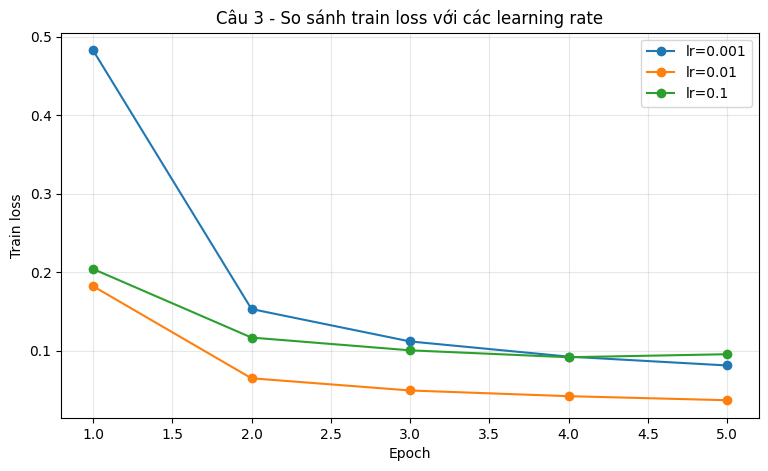


BẢNG KẾT QUẢ CÂU 3
lr=0.001 | Train loss cuối: 0.0813 | Test acc cuối: 98.12%
lr=0.01  | Train loss cuối: 0.0370 | Test acc cuối: 98.55%
lr=0.1   | Train loss cuối: 0.0956 | Test acc cuối: 97.16%


In [13]:
# Câu 3: So sánh learning rate

lr_list = [0.001, 0.01, 0.1]
ket_qua_lr = {}

for lr in lr_list:
    print(f'\n===== Train với learning rate = {lr} =====')

    torch.manual_seed(42)
    np.random.seed(42)

    model_lr = MNIST_CNN().to(device)
    model_lr, lich_su_lr = train_model_cnn(
        model=model_lr,
        train_loader=train_loader,
        test_loader=test_loader,
        num_epochs=5,
        lr=lr,
        momentum=0.9,
        ten_model=f'Câu 3 - lr={lr}'
    )

    ket_qua_lr[lr] = lich_su_lr

plt.figure(figsize=(9, 5))
for lr in lr_list:
    plt.plot(
        range(1, 6),
        ket_qua_lr[lr]['train_loss'],
        marker='o',
        label=f'lr={lr}'
    )

plt.xlabel('Epoch')
plt.ylabel('Train loss')
plt.title('Câu 3 - So sánh train loss với các learning rate')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print('\nBẢNG KẾT QUẢ CÂU 3')
for lr in lr_list:
    print(
        f'lr={lr:<5} | '
        f'Train loss cuối: {ket_qua_lr[lr]["train_loss"][-1]:.4f} | '
        f'Test acc cuối: {ket_qua_lr[lr]["test_acc"][-1]*100:.2f}%'
    )

**Nhận xét Câu 3:**  
`lr=0.001` thường học chậm vì mỗi lần cập nhật trọng số quá nhỏ, loss giảm từ từ.  
`lr=0.01` thường ổn định hơn, loss giảm nhanh và ít dao động.  
`lr=0.1` có thể học nhanh lúc đầu nhưng dễ dao động hoặc làm loss không ổn định vì bước cập nhật quá lớn.  
Learning rate ảnh hưởng trực tiếp đến độ lớn bước cập nhật trọng số, nên nó quyết định tốc độ và độ ổn định của quá trình học.

## Câu 4: Vẽ thêm feature maps từ conv2

Yêu cầu: lấy feature map từ `conv1` và `conv2`, sau đó vẽ để so sánh.  
`conv1` thường học cạnh, nét đơn giản.  
`conv2` thường học đặc trưng trừu tượng hơn vì nó nhận đầu vào từ feature maps của conv1.

Nhãn thật của ảnh: 7
Shape ảnh gốc: torch.Size([1, 1, 28, 28])
Shape feature map conv1: torch.Size([1, 16, 26, 26])
Shape feature map conv2: torch.Size([1, 32, 11, 11])


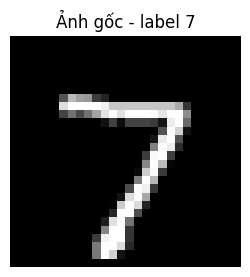

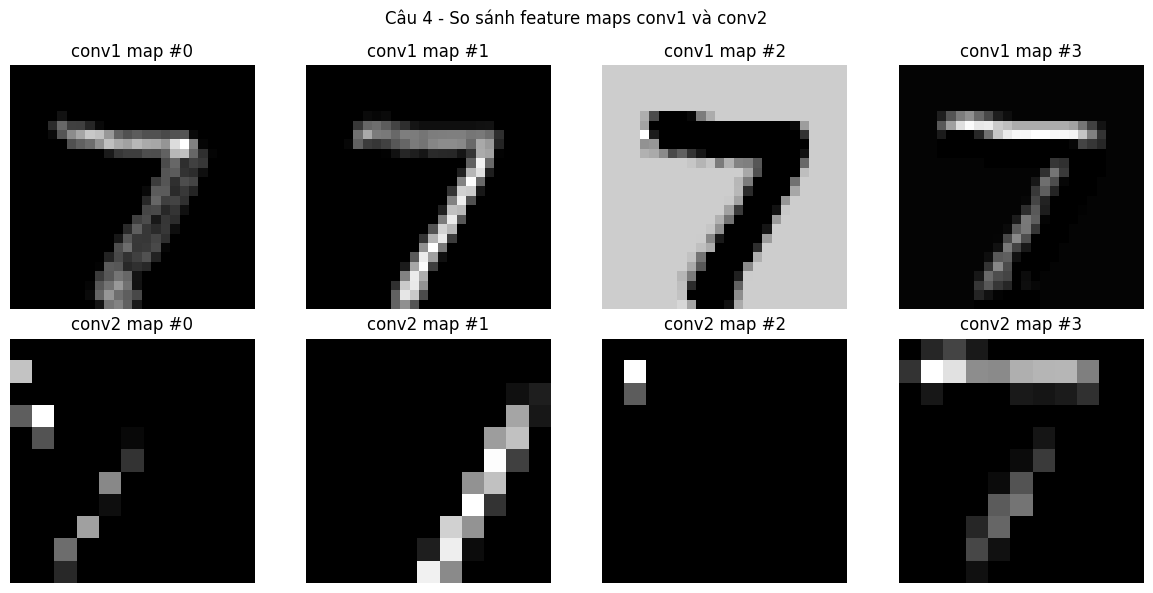

In [14]:
# Câu 4: Vẽ feature maps từ conv1 và conv2

# Dùng model đã train ở Câu 1 để feature map có ý nghĩa hơn.
model_feature = model_cau1
model_feature.eval()

images, labels = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)
label_that = labels[0].item()

with torch.no_grad():
    h1 = torch.relu(model_feature.conv1(img))   # feature map conv1: (1, 16, 26, 26)
    h1_pool = model_feature.pool(h1)
    h2 = torch.relu(model_feature.conv2(h1_pool))  # feature map conv2: (1, 32, 11, 11)

print('Nhãn thật của ảnh:', label_that)
print('Shape ảnh gốc:', img.shape)
print('Shape feature map conv1:', h1.shape)
print('Shape feature map conv2:', h2.shape)

plt.figure(figsize=(3, 3))
plt.imshow(img.cpu().squeeze() * 0.3081 + 0.1307, cmap='gray')
plt.title(f'Ảnh gốc - label {label_that}')
plt.axis('off')
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    axes[0, i].imshow(h1[0, i].cpu(), cmap='gray')
    axes[0, i].set_title(f'conv1 map #{i}')
    axes[0, i].axis('off')

for i in range(4):
    axes[1, i].imshow(h2[0, i].cpu(), cmap='gray')
    axes[1, i].set_title(f'conv2 map #{i}')
    axes[1, i].axis('off')

plt.suptitle('Câu 4 - So sánh feature maps conv1 và conv2')
plt.tight_layout()
plt.show()

**Nhận xét Câu 4:**  
Feature map của `conv1` thường còn khá gần với ảnh gốc, dễ thấy các cạnh, nét cong, nét thẳng của chữ số.  
Feature map của `conv2` trừu tượng hơn vì nó không nhìn trực tiếp ảnh gốc, mà nhìn các đặc trưng do `conv1` tạo ra.  
Vì vậy `conv2` thường thể hiện vùng hoặc tổ hợp nét quan trọng hơn thay vì từng cạnh đơn giản.

## Câu 5: Thêm Dropout và Data Augmentation

Yêu cầu:
- Thêm `Dropout(p=0.25)` sau pool cuối cùng và trước `fc1`.
- Thêm `RandomAffine(degrees=10, translate=(0.1, 0.1))` cho tập train.
- Không áp dụng augmentation cho tập test.
- Train 10 epoch và so sánh với model không dropout/augmentation.

Câu 5 - Baseline 10 epoch | Epoch [01/10] Train loss: 0.1824 | Train acc: 94.29% | Test loss: 0.0632 | Test acc: 97.92%
Câu 5 - Baseline 10 epoch | Epoch [02/10] Train loss: 0.0650 | Train acc: 98.06% | Test loss: 0.0562 | Test acc: 98.13%
Câu 5 - Baseline 10 epoch | Epoch [03/10] Train loss: 0.0495 | Train acc: 98.52% | Test loss: 0.0411 | Test acc: 98.70%
Câu 5 - Baseline 10 epoch | Epoch [04/10] Train loss: 0.0422 | Train acc: 98.69% | Test loss: 0.0501 | Test acc: 98.47%
Câu 5 - Baseline 10 epoch | Epoch [05/10] Train loss: 0.0370 | Train acc: 98.80% | Test loss: 0.0425 | Test acc: 98.55%
Câu 5 - Baseline 10 epoch | Epoch [06/10] Train loss: 0.0316 | Train acc: 99.06% | Test loss: 0.0327 | Test acc: 99.01%
Câu 5 - Baseline 10 epoch | Epoch [07/10] Train loss: 0.0283 | Train acc: 99.08% | Test loss: 0.0356 | Test acc: 98.89%
Câu 5 - Baseline 10 epoch | Epoch [08/10] Train loss: 0.0251 | Train acc: 99.18% | Test loss: 0.0364 | Test acc: 98.86%
Câu 5 - Baseline 10 epoch | Epoch [09/10

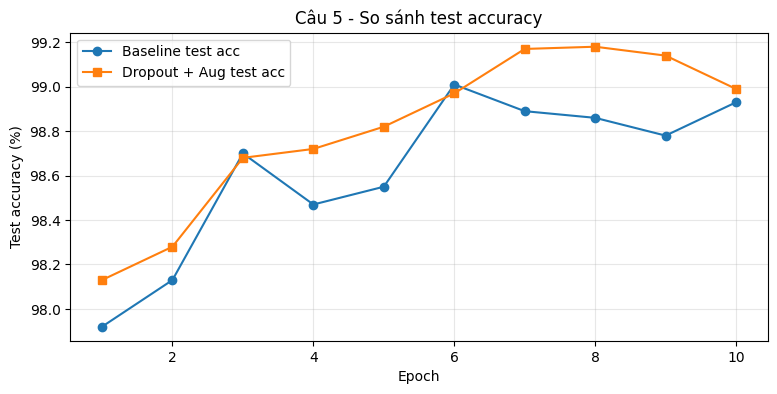

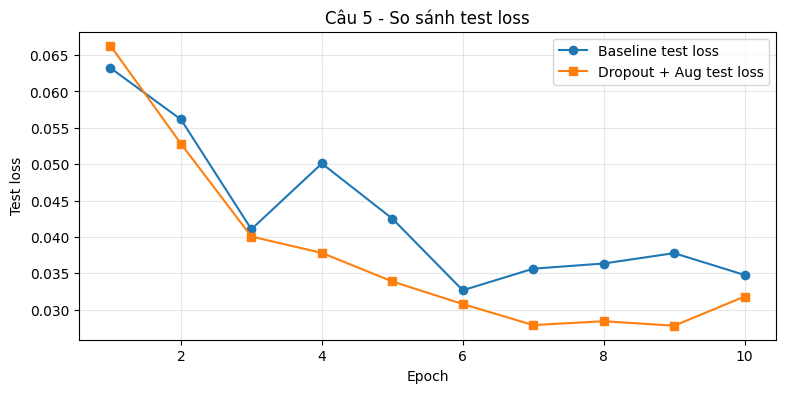

In [15]:
# Câu 5: Dropout + Data Augmentation

transform_train_aug = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

transform_test_no_aug = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset_aug = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform_train_aug
)

test_dataset_no_aug = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform_test_no_aug
)

train_loader_aug = torch.utils.data.DataLoader(
    train_dataset_aug,
    batch_size=64,
    shuffle=True
)

test_loader_no_aug = torch.utils.data.DataLoader(
    test_dataset_no_aug,
    batch_size=64,
    shuffle=False
)

class MNIST_CNN_Dropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(p=0.25)
        self.fc1 = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc1(x)
        return x

# Model baseline không dropout/augmentation, train 10 epoch
torch.manual_seed(42)
np.random.seed(42)

model_baseline_10 = MNIST_CNN().to(device)
model_baseline_10, lich_su_baseline_10 = train_model_cnn(
    model=model_baseline_10,
    train_loader=train_loader,
    test_loader=test_loader,
    num_epochs=10,
    lr=0.01,
    momentum=0.9,
    ten_model='Câu 5 - Baseline 10 epoch'
)

# Model có dropout + augmentation, train 10 epoch
torch.manual_seed(42)
np.random.seed(42)

model_dropout_aug = MNIST_CNN_Dropout().to(device)
model_dropout_aug, lich_su_dropout_aug = train_model_cnn(
    model=model_dropout_aug,
    train_loader=train_loader_aug,
    test_loader=test_loader_no_aug,
    num_epochs=10,
    lr=0.01,
    momentum=0.9,
    ten_model='Câu 5 - Dropout + Augmentation'
)

acc_baseline = lich_su_baseline_10['test_acc'][-1]
acc_dropout_aug = lich_su_dropout_aug['test_acc'][-1]
chenh_lech_cau5 = acc_dropout_aug - acc_baseline

print('\nKẾT QUẢ CÂU 5')
print(f'Baseline không dropout/augmentation - Test acc: {acc_baseline*100:.2f}%')
print(f'Dropout + augmentation - Test acc          : {acc_dropout_aug*100:.2f}%')
print(f'Chênh lệch: {chenh_lech_cau5*100:.2f}%')

epochs_cau5 = range(1, 11)

plt.figure(figsize=(9, 4))
plt.plot(epochs_cau5, [a * 100 for a in lich_su_baseline_10['test_acc']], 'o-', label='Baseline test acc')
plt.plot(epochs_cau5, [a * 100 for a in lich_su_dropout_aug['test_acc']], 's-', label='Dropout + Aug test acc')
plt.xlabel('Epoch')
plt.ylabel('Test accuracy (%)')
plt.title('Câu 5 - So sánh test accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(epochs_cau5, lich_su_baseline_10['test_loss'], 'o-', label='Baseline test loss')
plt.plot(epochs_cau5, lich_su_dropout_aug['test_loss'], 's-', label='Dropout + Aug test loss')
plt.xlabel('Epoch')
plt.ylabel('Test loss')
plt.title('Câu 5 - So sánh test loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Nhận xét Câu 5:**  
Dropout làm một phần neuron bị tắt ngẫu nhiên trong lúc train, khiến mô hình không phụ thuộc quá mạnh vào một vài đặc trưng cụ thể.  
Data augmentation tạo ra các biến thể ảnh như xoay nhẹ hoặc dịch nhẹ, giúp mô hình quen với nhiều dạng chữ số hơn.  
Hai kỹ thuật này thường giúp giảm overfitting vì mô hình khó học thuộc tập train hơn và có khả năng tổng quát tốt hơn trên test set.  
Nếu accuracy của mô hình có dropout/augmentation thấp hơn nhẹ ở vài epoch đầu, đó là bình thường vì bài toán train trở nên khó hơn.